In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

#read the csv file into a pandas dataframe
df = pd.read_csv("../data/e1_nutrients.csv")

#display the first 5 rows of the dataframe
display(df.head())

#print information about the dataframe
df.info()

#display descriptive statistics of the dataframe
display(df.describe())

#print the number of missing values in each column
print(df.isna().sum())

#separate the inputs and targets
X = df.drop(columns=["NITRITE"])
y = df["NITRITE"]

#create a KFold object with 5 splits, shuffling the data and setting a random state for reproducibility
cv = KFold(n_splits=5, shuffle=True, random_state=42)

#model building
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),
    "Neural Network": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(
            hidden_layer_sizes=(50, 25),
            max_iter=3000,
            random_state=42
        ))
    ])
}

,Depth,NITRITE,NITRATE+NITRITE,AMMONIA,SILICATE,PHOSPHATE
0,0,0.03,0.38,0.00,1.27,0.06
1,10,0.03,0.45,0.98,1.14,0.06
2,20,0.23,2.08,1.10,2.54,0.27
3,30,0.04,0.39,0.00,1.15,0.08
4,40,0.28,2.19,1.11,2.59,0.19


<class 'pandas.DataFrame'>
RangeIndex: 2496 entries, 0 to 2495
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Depth            2496 non-null   int64  
 1   NITRITE          2496 non-null   float64
 2   NITRATE+NITRITE  2496 non-null   float64
 3   AMMONIA          2496 non-null   float64
 4   SILICATE         2496 non-null   float64
 5   PHOSPHATE        2496 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 117.1 KB


,Depth,NITRITE,NITRATE+NITRITE,AMMONIA,SILICATE,PHOSPHATE
count,2496.000000,2496.000000,2496.000000,2496.000000,2496.000000,2496.000000
mean,26.919071,0.210601,2.905465,0.519247,1.939455,0.290741
std,19.729713,0.328292,2.260390,0.654011,1.076337,0.175216
min,0.000000,0.000000,0.000000,0.000000,0.040000,0.000000
25%,10.000000,0.040000,0.430000,0.100000,1.010000,0.160000
50%,30.000000,0.110000,3.030000,0.240000,2.080000,0.300000
75%,40.000000,0.230000,4.972500,0.640000,2.750000,0.410000
max,60.000000,2.900000,8.350000,4.170000,8.820000,2.560000


Depth              0
NITRITE            0
NITRATE+NITRITE    0
AMMONIA            0
SILICATE           0
PHOSPHATE          0
dtype: int64


## Data preparation

The dataset was loaded into Python using pandas and inspected using `head()`, `info()`, `describe()`, and `isna().sum()`. This showed that all variables were numeric and that there were no missing values, so no imputation was required. The target variable for prediction was `NITRITE`, while the remaining variables were used as input features.

Standardisation was used for linear regression and the neural network because these models are more sensitive to the scale of the input variables. Random forest was left unscaled because tree-based models do not require feature scaling in the same way. This preparation step helps ensure that each model is trained in an appropriate way for its learning method.

In [2]:
#EVALUATION OF MODELS USING CROSS VALIDATION
results = []

for name, model in models.items():
    scores = -cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="neg_mean_squared_error"
    )
    results.append({
        "Model": name,
        "Mean MSE": scores.mean(),
        "Std MSE": scores.std()
    })

results_df = pd.DataFrame(results)
display(results_df)

,Model,Mean MSE,Std MSE
0,Linear Regression,0.095249,0.009400
1,Random Forest,0.052304,0.011014
2,Neural Network,0.066714,0.009636


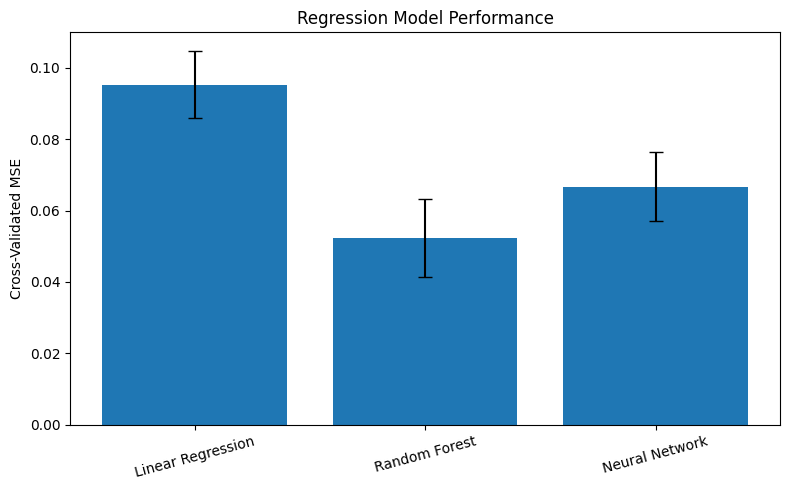

In [3]:
#PLOTTING RESULTS
#
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["Mean MSE"], yerr=results_df["Std MSE"], capsize=5)
plt.ylabel("Cross-Validated MSE")
plt.title("Regression Model Performance")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Regression analysis

The regression results show that the random forest model achieved the lowest mean cross-validated mean squared error, which suggests that it was the most accurate predictor of nitrite values on this dataset. The neural network performed better than linear regression, but it still had a higher average error than random forest. This suggests that the relationship between the predictor variables and nitrite is not purely linear, and that a model capable of capturing more complex patterns was more suitable.

The standard deviation values are also relatively small, which indicates that the models were reasonably consistent across the different cross-validation folds. Linear regression produced the highest mean squared error, which suggests that it was the least suitable model for this problem. Overall, random forest appears to be the best choice for this dataset because it gave the lowest prediction error while remaining stable across validation runs.

In [4]:
#DEMO OF PREDICTIONS
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test[:5])
    print(name)
    print("Predictions:", preds)
    print("True values:", y_test.iloc[:5].values)
    print()

Linear Regression
Predictions: [0.05170578 0.05131972 0.23181563 0.18182822 0.26940071]
True values: [0.   0.   0.17 0.19 2.61]

Random Forest
Predictions: [0.0000e+00 3.0000e-04 1.9555e-01 1.2605e-01 1.3947e+00]
True values: [0.   0.   0.17 0.19 2.61]

Neural Network
Predictions: [ 0.00963558 -0.01474953  0.09517791  0.14356181  0.60767818]
True values: [0.   0.   0.17 0.19 2.61]



## Optimisation setup

For the optimisation part of the assessment, the McCormick function was used as the fitness function. The aim was to minimise the function by searching for good values of `x` and `y`, with both decision variables initially generated in the range `-5` to `5`. Random solutions were first generated to visualise the search space before implementing the hillclimber and population-based evolutionary algorithm.

In [5]:
import math
import random

# optimisation
def mccormick(x, y): #takes 2 inputs here, x and y
    return math.sin(x + y) + (x - y)**2 - 1.5*x + 2.5*y + 1 #mccormick function here


In [6]:
#GENERATE RANDOM SOLUTIONS TO TEST OPTIMISATION
import numpy as np

random.seed(42) #set the random seed for reproducibility
np.random.seed(42) #set the numpy random seed for reproducibility

points = np.array([
    [random.uniform(-5, 5), random.uniform(-5, 5)]
    for _ in range(500) #generate 500 random points in the range [-5, 5] for both x and y
])

fitness = np.array([mccormick(x, y) for x, y in points])

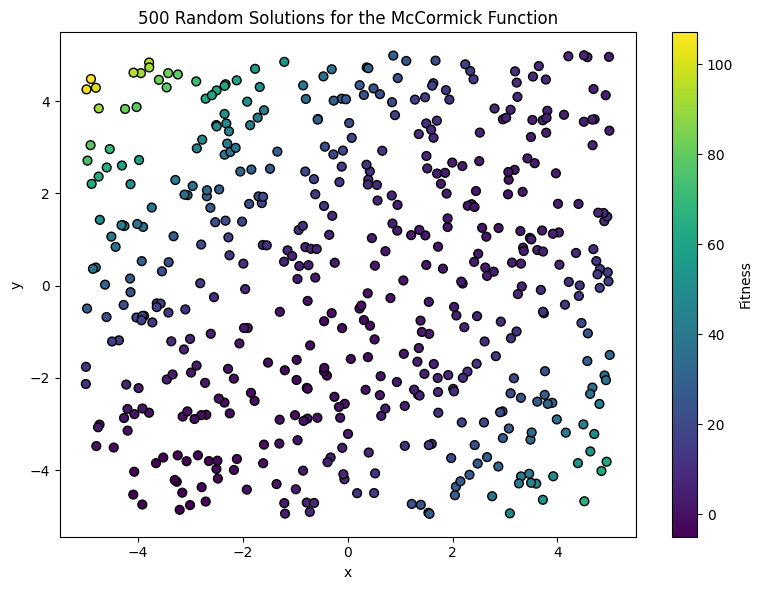

In [7]:
#plot the x and y values and colour the solutions according to their fitness value
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6)) #set the figure size for better visibility
scatter = plt.scatter( #create a scatter plot of the points, colouring them by their fitness value
    points[:, 0], points[:, 1], #x and y values from the points array
    c=fitness,
    cmap="viridis", #use the viridis colormap for better visibility of fitness values
    s=40, #set the size of the points
    edgecolor="black" #just the colour black for edges
)

plt.colorbar(scatter, label="Fitness") #add a colorbar to show the fitness values
plt.xlabel("x") #label for x-axis
plt.ylabel("y") #label for y-axis
plt.title("500 Random Solutions for the McCormick Function") #title for the plot
plt.tight_layout()
plt.show() #shows the plot




#This plot shows the spread of randomly generated candidae solutions across the search space, with colours indicating their fitness values according to the McCormick function. 
#The plot helps visualize how the random solutions are distributed and how their fitness varies across the search space.
#Lower fitness values indicate better solutions because te goal was to minimise the mccomick function.

## Optimisation analysis

The hillclimber improves the current solution by only accepting a mutated child when it has better fitness, so it makes steady local progress but can get stuck when no small change improves the solution. The evolutionary algorithm performs better because it keeps a population of candidate solutions, mutates them all, and then selects the best parent and child solutions each generation, which gives it more exploration and a better chance of finding a lower fitness value. In the fitness plot, this usually appears as the evolutionary algorithm reaching a better minimum than the hillclimber over time.

In [8]:
#HILLCLIMBER


In [9]:
# mutation operator that performs additive gaussian mutation
def gaussian_mutation(solution, sigma=0.2, lower=-5, upper=5): #
    child = solution + np.random.normal(0, sigma, size=2) #add gaussian noise to the solution to create a child solution
    child = np.clip(child, lower, upper) #
    return child

In [10]:
#HILLCLIMBER ALGORITHM
def hillclimber(iterations=200, sigma=0.2, lower=-5, upper=5, seed=42): #function to perform the hill climbing optimization
#note to self 
#increase the iterations for stronger search
#sigma will controls the step size


    random.seed(seed) #set the random seed for reproducibility
    np.random.seed(seed) #set the numpy random seed for reproducibility

    parent = np.array([ #initialise the parent solution with random values within the specified bounds
        random.uniform(lower, upper),
        random.uniform(lower, upper)
    ])

    parent_fitness = mccormick(parent[0], parent[1]) #evaluate the fitness of the initial parent solution using the McCormick function
    fitness_history = [parent_fitness] #list to keep track of the fitness values over iterations

    for _ in range(iterations): #repeats for the specified number of iterations
        child = gaussian_mutation(parent, sigma=sigma, lower=lower, upper=upper) #slightly modified the parent solution to create a child solution
        child_fitness = mccormick(child[0], child[1]) #evaluate the fitness of the child solution using the mccormick function

        if child_fitness < parent_fitness: #child better replace the parent
            parent = child
            parent_fitness = child_fitness

        fitness_history.append(parent_fitness) #store the better fitness after each generation

    return parent, parent_fitness, fitness_history


In [11]:
#RUNNING THE HILLCLIMBER
best_solution_hc, best_fitness_hc, history_hc = hillclimber()

print("Best solution found by hillclimber:", best_solution_hc)
print("Best fitness found by hillclimber:", best_fitness_hc)


Best solution found by hillclimber: [-0.54391197 -1.56531663]
Best fitness found by hillclimber: -1.9126697921707816


In [12]:
#POPULATION BASED EVOLUTIONARY ALGORITHM
def evolutionary_algorithm(pop_size=20, generations=200, sigma=0.2, lower=-5, upper=5, seed=42):
    random.seed(seed)
    np.random.seed(seed)

    parents = np.array([ #creates the intitial population of random solutions 
        [random.uniform(lower, upper), random.uniform(lower, upper)]
        for _ in range(pop_size)
    ])

    parent_fitness = np.array([ #evaluates the fitness of every parent
        mccormick(x, y) for x, y in parents
    ])

    fitness_history = [parent_fitness.min()] #stores the best fitness in the population for each gen 

    for _ in range(generations):
        children = np.array([ #mutates each parent to create a child population
            gaussian_mutation(parent, sigma=sigma, lower=lower, upper=upper)
            for parent in parents
        ])

        child_fitness = np.array([
            mccormick(x, y) for x, y in children
        ])

        combined_population = np.vstack((parents, children)) #combine parents and children into one population
        combined_fitness = np.concatenate((parent_fitness, child_fitness)) #combines the fitness values too 

        best_indices = np.argsort(combined_fitness)[:pop_size] #sorting the combined fitneess values and only keeps the best pop_size ones

        parents = combined_population[best_indices]
        parent_fitness = combined_fitness[best_indices]

        fitness_history.append(parent_fitness.min())

    best_index = np.argmin(parent_fitness)

    return parents[best_index], parent_fitness[best_index], fitness_history

In [13]:
#RUNNING THE EVOLUTIONARY ALGORITHM
best_solution_ea, best_fitness_ea, history_ea = evolutionary_algorithm()

print("Best solution found by evolutionary algorithm:", best_solution_ea)
print("Best fitness found by evolutionary algorithm:", best_fitness_ea)

Best solution found by evolutionary algorithm: [-3.69572095 -4.68890039]
Best fitness found by evolutionary algorithm: -5.054747651212645


# PLOT COMPARING THE CHANGE IN FITNESS OVER THE RUNTIME OF THE ALGORITHMS
plt.figure(figsize=(9, 5))

plt.plot(history_hc, label="Hillclimber", linewidth=2)
plt.plot(history_ea, label="Evolutionary Algorithm", linewidth=2)

plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.title("Fitness Over Time")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Optimisation analysis

The hillclimber improved the starting solution by repeatedly accepting only mutated solutions that had a better fitness value. This allowed it to make steady progress, but because it only works from a single current solution, it can become stuck when small mutations no longer produce improvements. This means it is effective for local search, but it has limited ability to explore different areas of the search space.

The evolutionary algorithm performed better because it worked with a population of candidate solutions instead of only one. By mutating all parent solutions, combining the parent and child populations, and selecting the best solutions for the next generation, it was able to search more broadly and retain stronger candidates over time. In the comparison plot, the evolutionary algorithm reached a lower best fitness than the hillclimber, which suggests that the population-based approach was more effective for minimising the McCormick function.

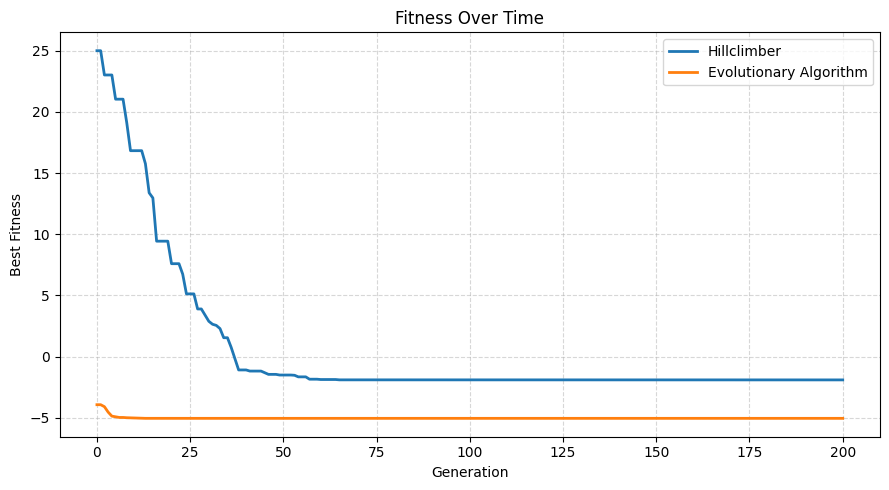

In [14]:
#PLOT COMPARING THE CHANGE IN FITNESS OVER THE RUNTIME OF THE ALGORITHMS
plt.figure(figsize=(9, 5))

plt.plot(history_hc, label="Hillclimber", linewidth=2)
plt.plot(history_ea, label="Evolutionary Algorithm", linewidth=2)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.title("Fitness Over Time")
plt.legend()
plt.tight_layout()
plt.show()